In [1]:
import numpy as np

import sys
sys.path.append('./src')

Coordinates:
[[41.65594923 30.68311612]
 [98.64005342 16.94902651]
 [25.38131288 88.9729249 ]
 [60.46327824 41.20406794]]

Distance Matrix:
[[  0.          58.61581141  60.51913412  21.5500824 ]
 [ 58.61581141   0.         102.73404988  45.23022438]
 [ 60.51913412 102.73404988   0.          59.26725899]
 [ 21.5500824   45.23022438  59.26725899   0.        ]]


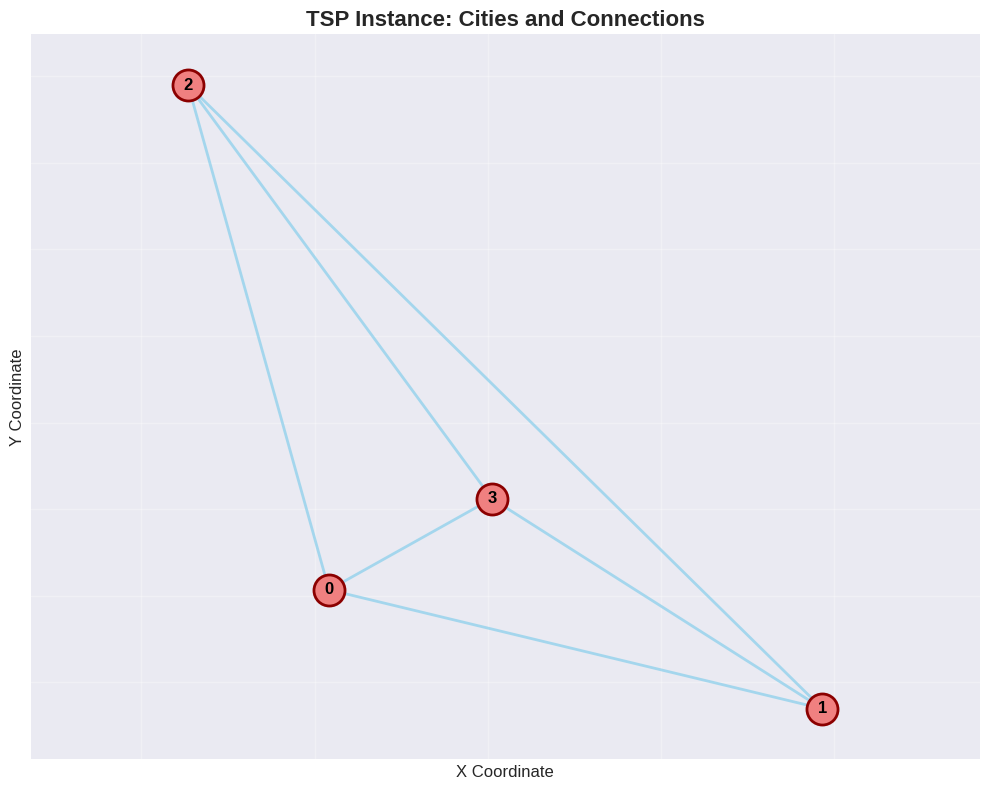

In [2]:
from tsp import TSPInstance

n_cities = 4  # Change this to the desired number of cities
tsp_instance = TSPInstance(n_cities)
print("Coordinates:")
print(tsp_instance.coords)
print("\nDistance Matrix:")
print(tsp_instance.dist_matrix)

# Plot the instance
tsp_instance.plot_tsp_instance()

In [3]:
from bloch_sphere_encoding import BlochSphereEncoder

encoder = BlochSphereEncoder(tsp_instance)
bloch_tsp = encoder.get_encoded_instance()

bloch_tsp.plot_all_cities_on_bloch_sphere()

In [4]:
bloch_tsp.plot_all_states_on_bloch_sphere()

In [5]:
list = bloch_tsp.travel_operators

for i in range(len(list)):
    for j in range(len(list[i])):
        if list[i][j] is not None:
            print(f"Operator from city {list[i][j].from_city} to city {list[i][j].to_city}:")
            print(f"  Up state: {list[i][j].up}")
            print(f"  Down state: {list[i][j].down}")
            print(f"  Cost: {list[i][j].cost}\n")
        else:
            
            print(list[i][j])

None
Operator from city 0 to city 1:
  Up state: Operator([[0.6672666 +0.j, 0.6672666 +0.j],
          [0.23399846+0.j, 0.23399846+0.j]],
         input_dims=(2,), output_dims=(2,))
  Down state: Operator([[6.67266602e-01+0.j        , 2.33998465e-01+0.j        ],
          [4.08582954e-17+0.6672666j , 1.43282735e-17+0.23399846j]],
         input_dims=(2,), output_dims=(2,))
  Cost: 0.8962315937818394

Operator from city 0 to city 2:
  Up state: Operator([[0.67060072+0.j, 0.67060072+0.j],
          [0.22426475+0.j, 0.22426475+0.j]],
         input_dims=(2,), output_dims=(2,))
  Down state: Operator([[ 0.67060072+0.00000000e+00j,  0.22426475+0.00000000e+00j],
          [-0.67060072+8.21249022e-17j, -0.22426475+2.74645108e-17j]],
         input_dims=(2,), output_dims=(2,))
  Cost: 0.9253332628862005

Operator from city 0 to city 3:
  Up state: Operator([[0.5752324 +0.j, 0.5752324 +0.j],
          [0.41122705+0.j, 0.41122705+0.j]],
         input_dims=(2,), output_dims=(2,))
  Down state: 

In [6]:
initial_state = bloch_tsp.get_city_state(0)

expected_final_state = bloch_tsp.get_city_state(2)

travel_operator = bloch_tsp.travel_operators[0][2]
computed_final_state = initial_state.evolve(travel_operator.up).evolve(travel_operator.down)

print("Initial State (City 0):", initial_state)
print("Expected Final State (City 2):", expected_final_state)
print("Computed Final State after applying travel operator:", computed_final_state)
print("States match:", np.allclose(expected_final_state.data, computed_final_state.data))

Initial State (City 0): Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Expected Final State (City 2): Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
Computed Final State after applying travel operator: Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
States match: True


In [7]:
routes = bloch_tsp.get_allowed_routes()
print("Allowed Routes:")
for route in routes:
    print(route)

Allowed Routes:
(0, 1, 2, 3, 0)
(0, 1, 3, 2, 0)
(0, 2, 1, 3, 0)
(0, 2, 3, 1, 0)
(0, 3, 1, 2, 0)
(0, 3, 2, 1, 0)
